In [9]:
"""
build_graph.py
==============
Downloads the Bristol walking graph, scores every edge for safety
(CCTV + street lights within 40 m), and writes three edge attributes:
 
    safety_density  : raw (cctv*2 + lights) / length  — kept for reference
    safety_score    : normalised [0, 1] — 1 = densest coverage
    safety_weight   : routing weight used by safe_route.py
                      lower  = safer (more cameras / lights)
                      formula: length * (1 + penalty)
                      where penalty = (1 - safety_score) scaled by SAFETY_FACTOR
 
Usage
-----
    python build_graph.py
 
Outputs
-------
    bristol_safety_graph.pkl   — enriched MultiDiGraph
    cctv.gpkg                  — CCTV GeoPackage  (for plotting)
    lights.gpkg                — street-lights GeoPackage (for plotting)
"""
 
import pickle
 
import geopandas as gpd
import networkx as nx
import osmnx as ox
import pandas as pd
from pyproj import Transformer
from shapely.geometry import Point
 
# ── Paths ─────────────────────────────────────────────────────────────────────
CCTV_CSV   = "Council_cctv_cameras_longlat.csv"
LIGHTS_CSV = "Council_streetlights_longlat.csv"
OUT_GRAPH  = "bristol_safety_graph.pkl"
OUT_CCTV   = "cctv.gpkg"
OUT_LIGHTS = "lights.gpkg"
 
# How strongly safety infrastructure bends the routing cost.
# 0 = ignored entirely, 1 = unsafe edge costs up to 2× its physical length.
SAFETY_FACTOR = 0.8
 
BUFFER_M = 40   # metres radius around each edge midpoint
 
 
# ── Load data ─────────────────────────────────────────────────────────────────
print("Downloading Bristol walk graph …")
G = ox.graph_from_place("Bristol, United Kingdom", network_type="walk")
 
cctv_df   = pd.read_csv(CCTV_CSV)
lights_df = pd.read_csv(LIGHTS_CSV)
 
cctv_gdf = gpd.GeoDataFrame(
    cctv_df,
    geometry=gpd.points_from_xy(cctv_df.longitude, cctv_df.latitude),
    crs="EPSG:4326",
).to_crs(epsg=3857)
 
lights_gdf = gpd.GeoDataFrame(
    lights_df,
    geometry=gpd.points_from_xy(lights_df.longitude, lights_df.latitude),
    crs="EPSG:4326",
).to_crs(epsg=3857)
 
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
 
 
# ── Safety scoring ────────────────────────────────────────────────────────────
def raw_safety_score(point: Point) -> float:
    """Count cameras and lights within BUFFER_M of an edge midpoint."""
    buf = point.buffer(BUFFER_M)
    n_cctv   = cctv_gdf[cctv_gdf.intersects(buf)].shape[0]
    n_lights = lights_gdf[lights_gdf.intersects(buf)].shape[0]
    return float(n_cctv * 2 + n_lights)
 
 
print("Scoring edges … (this may take a few minutes)")
total = G.number_of_edges()
raw_scores: dict[tuple, float] = {}
 
for i, (u, v, k, data) in enumerate(G.edges(keys=True, data=True)):
    if i % 1000 == 0:
        print(f"  {i:,} / {total:,} edges done …")
 
    x1, y1 = transformer.transform(G.nodes[u]["x"], G.nodes[u]["y"])
    x2, y2 = transformer.transform(G.nodes[v]["x"], G.nodes[v]["y"])
    mid     = Point((x1 + x2) / 2, (y1 + y2) / 2)
    score   = raw_safety_score(mid)
    length  = data.get("length", 1.0)
 
    data["safety_density"] = score / length   # raw density (for reference)
    raw_scores[(u, v, k)] = score
 
 
# ── Normalise and write safety_weight ────────────────────────────────────────
all_raw = list(raw_scores.values())
s_min, s_max = min(all_raw), max(all_raw)
span = (s_max - s_min) or 1.0
 
print("Writing normalised safety_score and safety_weight …")
for u, v, k, data in G.edges(keys=True, data=True):
    raw    = raw_scores[(u, v, k)]
    norm   = (raw - s_min) / span            # 0 = no coverage, 1 = densest
 
    data["safety_score"] = norm
 
    # Routing weight: shorter physical edges that are well-covered are cheapest.
    # Edges with no cameras/lights get up to (1 + SAFETY_FACTOR)× the penalty.
    length = data.get("length", 1.0)
    penalty = (1.0 - norm) * SAFETY_FACTOR   # 0 when fully covered, SAFETY_FACTOR when dark
    data["safety_weight"] = length * (1.0 + penalty)
 
 
# ── Save ──────────────────────────────────────────────────────────────────────
print(f"\nSaving graph → {OUT_GRAPH}")
with open(OUT_GRAPH, "wb") as f:
    pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
 
cctv_gdf.to_crs(epsg=4326).to_file(OUT_CCTV, driver="GPKG")
lights_gdf.to_crs(epsg=4326).to_file(OUT_LIGHTS, driver="GPKG")
 
print("Done! Graph has three safety attributes on every edge:")
print("  safety_density  — raw (cctv*2 + lights) / length")
print("  safety_score    — normalised [0, 1]")
print("  safety_weight   — routing cost (use with nx.shortest_path / astar_path)")

Scoring edges … (this may take a few minutes)
  0 / 99,400 edges done …
  1,000 / 99,400 edges done …
  2,000 / 99,400 edges done …
  3,000 / 99,400 edges done …
  4,000 / 99,400 edges done …
  5,000 / 99,400 edges done …
  6,000 / 99,400 edges done …
  7,000 / 99,400 edges done …
  8,000 / 99,400 edges done …
  9,000 / 99,400 edges done …
  10,000 / 99,400 edges done …
  11,000 / 99,400 edges done …
  12,000 / 99,400 edges done …
  13,000 / 99,400 edges done …
  14,000 / 99,400 edges done …
  15,000 / 99,400 edges done …
  16,000 / 99,400 edges done …
  17,000 / 99,400 edges done …
  18,000 / 99,400 edges done …
  19,000 / 99,400 edges done …
  20,000 / 99,400 edges done …
  21,000 / 99,400 edges done …
  22,000 / 99,400 edges done …
  23,000 / 99,400 edges done …
  24,000 / 99,400 edges done …
  25,000 / 99,400 edges done …
  26,000 / 99,400 edges done …
  27,000 / 99,400 edges done …
  28,000 / 99,400 edges done …
  29,000 / 99,400 edges done …
  30,000 / 99,400 edges done …
  31,00

Loading graph: bristol_safety_graph.pkl

Computing crime density …
  Loading crime data …
  CuPy not found — using scipy CPU KDE …
  KDE fit: 0.1s

Updating edge safety weights …

Saving weighted graph → bristol_weighted_graph.pkl

Finding routes …

========== ROUTE SUMMARY ==========
  A  Distance only:             3866 m  |  46 min
  B  Distance + Crime:          5424 m  |  1h 5min
  C  Distance + Crime + Safety: 5067 m  |  1h 1min

  Taking the full-safety route adds 1201 m (14 min) to your journey.



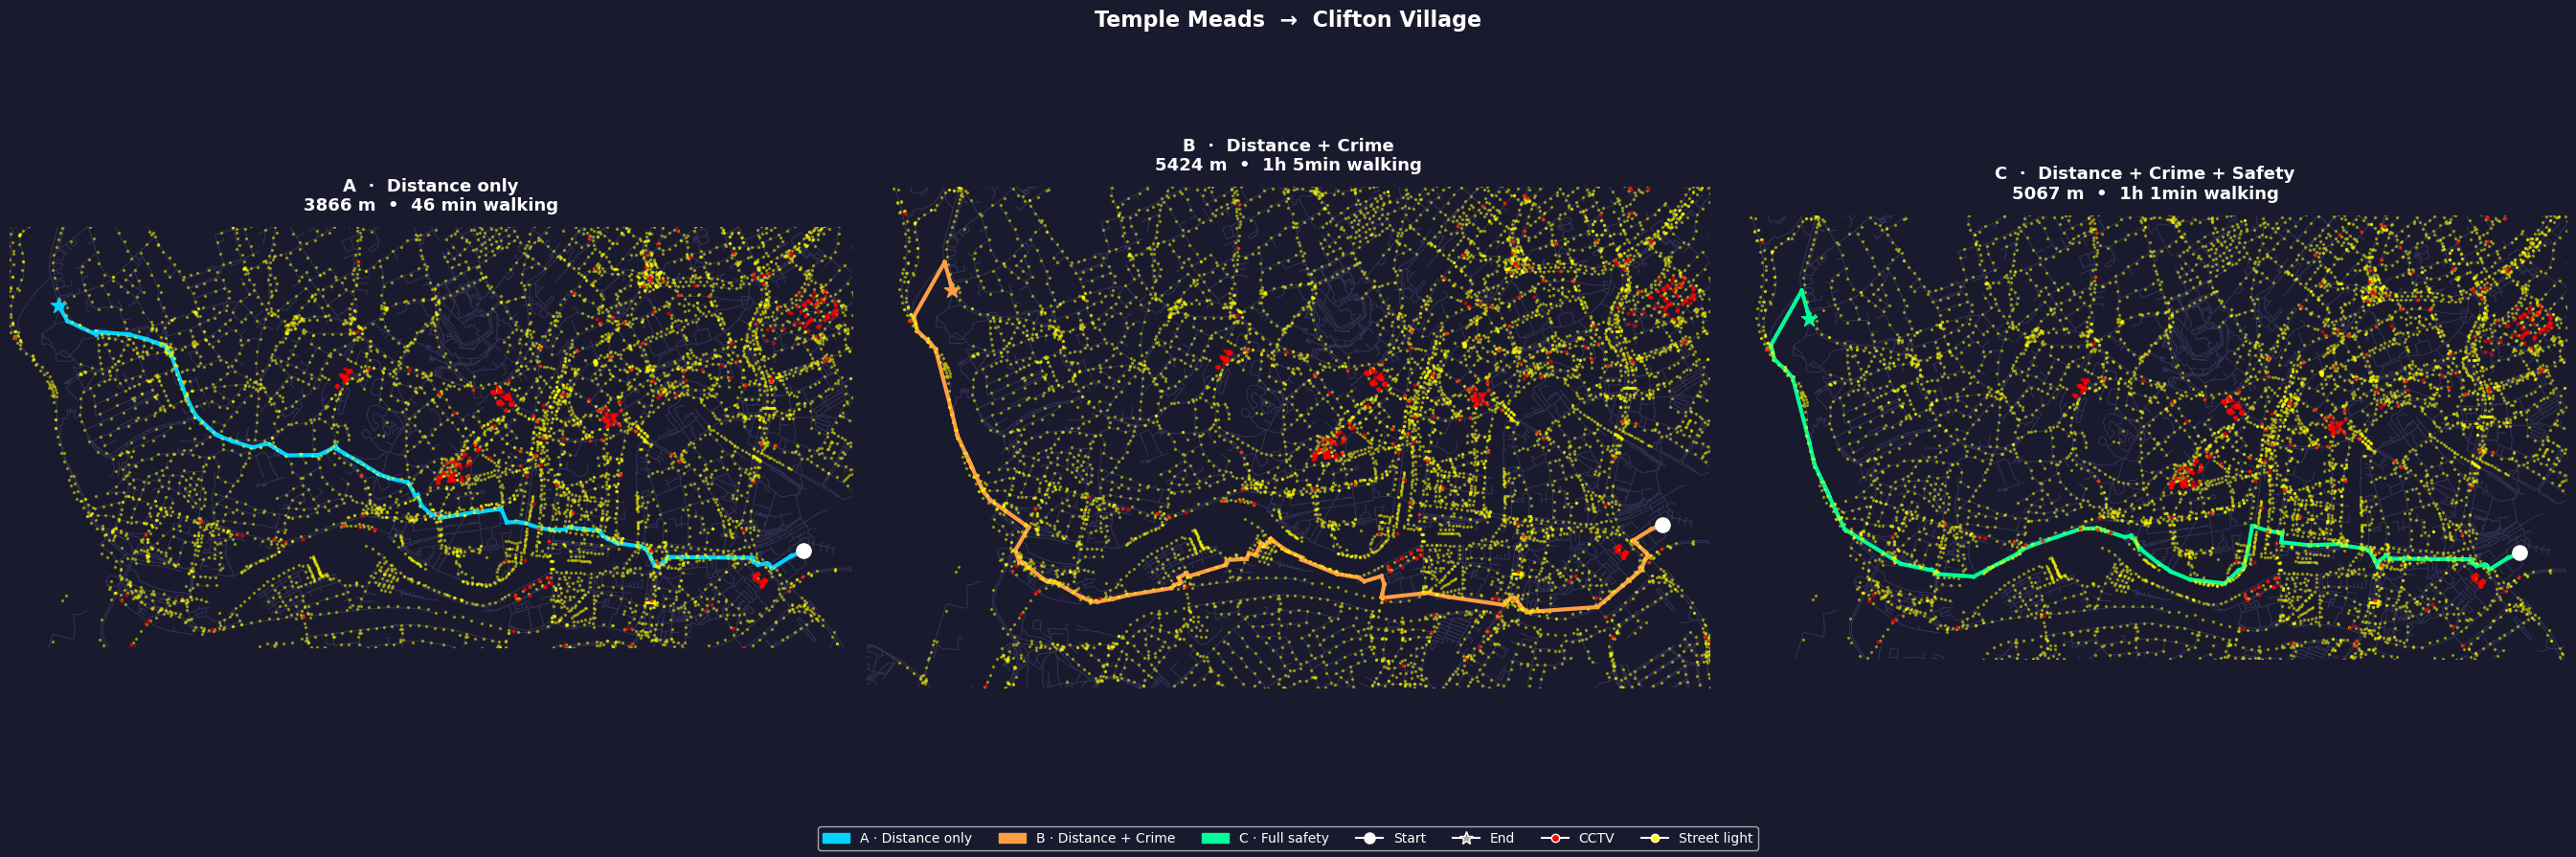

In [14]:
"""
safe_route.py  —  Bristol Safe Walking Router (Heat Method)
===========================================================
Geodesic routing that avoids crime hotspots, stays near CCTV cameras,
prefers lit streets, and minimises fast / dangerous roads.

Visualisation style matches the A* side-by-side dark-theme layout:
  • Dark #1a1a2e background
  • Two panels: quickest route (cyan) vs safest route (green)
  • CCTV = red dots, street lights = yellow dots
  • White circle start, coloured star end
  • Shared legend at bottom centre

Usage
-----
    python safe_route.py                         # uses config.yaml
    python safe_route.py --config my_cfg.yaml
"""

from __future__ import annotations

import argparse
import hashlib
import json
import os
import pickle
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import branca.colormap as cm
import folium
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import yaml
from folium.plugins import HeatMap
from scipy.sparse import csr_matrix, diags, lil_matrix
from scipy.sparse.linalg import spsolve
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler


# ════════════════════════════════════════════════════════════════════════════
# 1. Config helpers
# ════════════════════════════════════════════════════════════════════════════

def load_config(config_path: str) -> dict:
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def resolve_path(base_dir: Path, raw_path: str) -> Path:
    p = Path(raw_path)
    return p if p.is_absolute() else base_dir / p


# ════════════════════════════════════════════════════════════════════════════
# 2. Crime KDE  (unchanged from your original)
# ════════════════════════════════════════════════════════════════════════════

def build_crime_scores(G: nx.MultiDiGraph, cfg: dict, base_dir: Path) -> dict:
    """Read crime CSV, run weighted KDE, return {node_id: crime_score [0,1]}."""
    crime_path = resolve_path(base_dir, cfg["paths"]["crime_csv"])
    kde_cfg    = cfg["kde"]
    severity   = cfg["severity"]

    print("  Loading crime data …")
    df = pd.read_csv(crime_path)
    df["severity"] = df["crime_type"].map(severity).fillna(0.5)

    min_sev = kde_cfg.get("min_severity", 0.0)
    if min_sev > 0:
        before = len(df)
        df = df[df["severity"] >= min_sev]
        print(f"  Severity filter: {before:,} → {len(df):,} records")

    LAT0, LON0 = 51.45, -2.60
    coords_m = np.stack([
        (df["lat"].values  - LAT0) * 111_320,
        (df["lon"].values  - LON0) * 111_320 * np.cos(np.radians(LAT0)),
    ], axis=1).astype(np.float32)
    weights = df["severity"].values.astype(np.float32)
    weights = weights / weights.sum()

    bw_metres  = kde_cfg.get("bandwidth_metres", 150)
    node_ids   = list(G.nodes)
    node_coords_m = np.stack([
        (np.array([G.nodes[n]["y"] for n in node_ids]) - LAT0) * 111_320,
        (np.array([G.nodes[n]["x"] for n in node_ids]) - LON0) * 111_320 * np.cos(np.radians(LAT0)),
    ], axis=1).astype(np.float32)

    try:
        import cupy as cp
        _ = cp.array([1.0], dtype=cp.float32) ** 2
        crime_gpu = cp.asarray(coords_m)
        nodes_gpu = cp.asarray(node_coords_m)
        w_gpu     = cp.asarray(weights)
        free_mem  = cp.cuda.Device(0).mem_info[0]
        n_crime   = len(crime_gpu)
        BATCH     = int(free_mem * 0.75 / (3 * n_crime * 4))
        BATCH     = max(256, min(BATCH, len(nodes_gpu)))
        print(f"  GPU KDE: {n_crime:,} crime pts, batch={BATCH}")
        t0      = time.time()
        bw2     = cp.float32(bw_metres ** 2)
        crime_sq = cp.sum(crime_gpu ** 2, axis=1)
        chunks  = []
        for i in range(0, len(nodes_gpu), BATCH):
            batch   = nodes_gpu[i: i + BATCH]
            node_sq = cp.sum(batch ** 2, axis=1, keepdims=True)
            cross   = batch @ crime_gpu.T
            sq_dist = node_sq + crime_sq[None, :] - 2 * cross
            chunks.append(cp.asnumpy(cp.exp(-0.5 * sq_dist / bw2) @ w_gpu))
        density = np.concatenate(chunks)
        print(f"  GPU KDE complete: {time.time() - t0:.1f}s")

    except (ImportError, Exception) as e:
        if not isinstance(e, ImportError):
            print(f"  CuPy error ({type(e).__name__}) — falling back to scipy …")
        else:
            print("  CuPy not found — using scipy CPU KDE …")
        from scipy.stats import gaussian_kde as gkde
        t0  = time.time()
        kde = gkde(coords_m.T, bw_method=bw_metres / coords_m.std(), weights=weights)
        print(f"  KDE fit: {time.time() - t0:.1f}s")
        density = kde(node_coords_m.T)

    crime_scores = MinMaxScaler().fit_transform(density.reshape(-1, 1)).flatten()
    return dict(zip(node_ids, crime_scores))


# ════════════════════════════════════════════════════════════════════════════
# 3. Edge weight update
#    Writes:  crime_weight  and  safety_weight
#    NOTE: safety_weight here uses crime + lighting/CCTV (KDE-based).
#          The graph builder also writes a separate safety_weight from
#          raw CCTV/light counts — this function overwrites it if called.
# ════════════════════════════════════════════════════════════════════════════

def update_safety_weights(G: nx.MultiDiGraph, node_crime: dict, cfg: dict):
    k1 = cfg["weights"]["k1"]
    k2 = cfg["weights"]["k2"]
    k3 = cfg["weights"]["k3"]
    assert abs(k1 + k2 + k3 - 1.0) < 1e-6, "k1 + k2 + k3 must equal 1.0"

    lengths, crime_scores, safety_scores = [], [], []
    for u, v, data in G.edges(data=True):
        lengths.append(data.get("length", 1.0))
        crime_scores.append((node_crime.get(u, 0) + node_crime.get(v, 0)) / 2.0)
        safety_scores.append(data.get("safety_density", 0.0))

    def normalise(values):
        lo, hi = min(values), max(values)
        span = (hi - lo) or 1.0
        return [(v - lo) / span for v in values]

    norm_lengths  = normalise(lengths)
    norm_crimes   = normalise(crime_scores)
    norm_safeties = normalise(safety_scores)

    for (u, v, data), nl, nc, ns in zip(
        G.edges(data=True), norm_lengths, norm_crimes, norm_safeties
    ):
        k12 = (k1 + k2) or 1.0
        data["crime_weight"]  = (k1 / k12) * nl + (k2 / k12) * nc
        # safety_weight: lower is better  →  high safety_density lowers cost
        data["safety_weight"] = k1 * nl + k2 * nc + k3 * (1.0 - ns)


# ════════════════════════════════════════════════════════════════════════════
# 4. Routing helpers
# ════════════════════════════════════════════════════════════════════════════

def find_routes(G: nx.MultiDiGraph, cfg: dict):
    rc  = cfg["route"]
    sn  = ox.distance.nearest_nodes(G, rc["start"]["lon"], rc["start"]["lat"])
    gn  = ox.distance.nearest_nodes(G, rc["end"]["lon"],   rc["end"]["lat"])

    quickest    = nx.shortest_path(G, sn, gn, weight="length")
    crime_route = nx.astar_path(G,   sn, gn, weight="crime_weight")
    safest      = nx.astar_path(G,   sn, gn, weight="safety_weight")
    return sn, gn, quickest, crime_route, safest


def route_stats(G: nx.MultiDiGraph, route: list, speed_kmh: float):
    total_m = sum(G[u][v][0].get("length", 0) for u, v in zip(route[:-1], route[1:]))
    minutes = (total_m / 1000 / speed_kmh) * 60
    return total_m, minutes


def format_time(minutes: float) -> str:
    if minutes < 60:
        return f"{int(round(minutes))} min"
    h = int(minutes // 60)
    m = int(round(minutes % 60))
    return f"{h}h {m}min"


# ════════════════════════════════════════════════════════════════════════════
# 5. Visualisation  —  A*-style dark side-by-side panels
# ════════════════════════════════════════════════════════════════════════════

def _draw_route_on_ax(ax, G, route, colour, start_node, goal_node,
                      cctv_gdf, lights_gdf, title):
    """Render one route panel in the A*-matching dark style."""
    ox.plot_graph(
        G, ax=ax,
        node_size=0,
        edge_color="#333355",
        edge_linewidth=0.5,
        bgcolor="#1a1a2e",
        show=False,
        close=False,
    )

    # Route line
    edge_xs, edge_ys = [], []
    for u, v in zip(route[:-1], route[1:]):
        edge_xs += [G.nodes[u]["x"], G.nodes[v]["x"], None]
        edge_ys += [G.nodes[u]["y"], G.nodes[v]["y"], None]
    ax.plot(edge_xs, edge_ys, color=colour, linewidth=3, zorder=4)

    # Markers
    ax.scatter(G.nodes[start_node]["x"], G.nodes[start_node]["y"],
               c="white", s=120, zorder=6, marker="o")
    ax.scatter(G.nodes[goal_node]["x"],  G.nodes[goal_node]["y"],
               c=colour,  s=150, zorder=6, marker="*")

    # Safety overlays
    cctv_gdf.plot(ax=ax,   color="red",    markersize=4, zorder=5, alpha=0.6)
    lights_gdf.plot(ax=ax, color="yellow", markersize=2, zorder=4, alpha=0.4)

    # Zoom to route
    xs = [G.nodes[n]["x"] for n in route]
    ys = [G.nodes[n]["y"] for n in route]
    margin = 0.003
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)

    ax.set_title(title, color="white", fontsize=13, fontweight="bold", pad=12)
    ax.set_axis_off()


def plot_routes(G, start_node, goal_node,
                quickest, crime_route, safest,
                cctv_gdf, lights_gdf, cfg):
    speed = cfg["route"]["walking_speed_kmh"]

    quick_dist, quick_mins = route_stats(G, quickest,    speed)
    crime_dist, crime_mins = route_stats(G, crime_route, speed)
    safe_dist,  safe_mins  = route_stats(G, safest,      speed)

    fig, axes = plt.subplots(1, 3, figsize=(27, 9))
    fig.patch.set_facecolor("#1a1a2e")

    panels = [
        (quickest,    "#00d4ff", f"A  ·  Distance only\n{quick_dist:.0f} m  •  {format_time(quick_mins)} walking"),
        (crime_route, "#ff9f43", f"B  ·  Distance + Crime\n{crime_dist:.0f} m  •  {format_time(crime_mins)} walking"),
        (safest,      "#00ff99", f"C  ·  Distance + Crime + Safety\n{safe_dist:.0f} m  •  {format_time(safe_mins)} walking"),
    ]

    for ax, (route, colour, title) in zip(axes, panels):
        _draw_route_on_ax(ax, G, route, colour, start_node, goal_node,
                          cctv_gdf, lights_gdf, title)

    legend_handles = [
        mpatches.Patch(color="#00d4ff", label="A · Distance only"),
        mpatches.Patch(color="#ff9f43", label="B · Distance + Crime"),
        mpatches.Patch(color="#00ff99", label="C · Full safety"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="white",   markersize=8,  label="Start"),
        plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="#aaaaaa", markersize=10, label="End"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red",     markersize=6,  label="CCTV"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="yellow",  markersize=6,  label="Street light"),
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=7,
        facecolor="#1a1a2e", labelcolor="white", fontsize=10, framealpha=0.8,
    )

    start_name = cfg["route"]["start"]["name"]
    end_name   = cfg["route"]["end"]["name"]
    plt.suptitle(
        f"{start_name}  →  {end_name}",
        color="white", fontsize=16, fontweight="bold", y=0.98,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])

    print("\n========== ROUTE SUMMARY ==========")
    print(f"  A  Distance only:             {quick_dist:.0f} m  |  {format_time(quick_mins)}")
    print(f"  B  Distance + Crime:          {crime_dist:.0f} m  |  {format_time(crime_mins)}")
    print(f"  C  Distance + Crime + Safety: {safe_dist:.0f} m  |  {format_time(safe_mins)}")
    extra_m    = safe_dist  - quick_dist
    extra_mins = safe_mins  - quick_mins
    if extra_m > 0:
        print(f"\n  Taking the full-safety route adds {extra_m:.0f} m "
              f"({format_time(extra_mins)}) to your journey.")
    else:
        print("\n  The safest route is also the shortest — lucky!")
    print("====================================\n")

    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# 6. Heat-method visualisation  —  now styled to match the A* panels
# ════════════════════════════════════════════════════════════════════════════

def plot_heatmap_astar_style(
    G,
    distances: dict,
    origin_node: int,
    cctv_gdf,
    lights_gdf,
    dest_node: Optional[int] = None,
    path_nodes: Optional[list] = None,
    origin_label: str = "Origin",
    dest_label: str   = "Destination",
    output_file: str  = "bristol_safety_map.png",
):
    """
    Render the Heat-Method geodesic field with the same dark aesthetic
    as the A* side-by-side plots.

    - Background: #1a1a2e
    - Nodes coloured by routing cost (plasma palette)
    - Road edges: #333355 at 0.5 px
    - Route overlay (if path_nodes): cyan glow line
    - CCTV: red dots, lights: yellow dots
    - Start: white circle, End: cyan star
    - Legend bottom-centre, suptitle at top
    """
    # ── Colour nodes by geodesic cost ────────────────────────────────────────
    node_list  = list(G.nodes(data=True))
    dist_vals  = np.array([distances.get(n, np.nan) for n, _ in node_list])
    valid      = ~np.isnan(dist_vals)
    d_min      = float(dist_vals[valid].min())
    d_max      = float(dist_vals[valid].max())
    norm       = mcolors.Normalize(vmin=d_min, vmax=d_max)
    cmap       = plt.cm.plasma
    node_colors = [cmap(norm(distances.get(n, d_max))) for n, _ in node_list]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    # Base graph (dark edges, coloured nodes)
    ox.plot_graph(
        G, ax=ax,
        node_color=node_colors,
        node_size=6,
        edge_color="#333355",
        edge_linewidth=0.5,
        bgcolor="#1a1a2e",
        show=False,
        close=False,
    )

    # ── Safety overlays ───────────────────────────────────────────────────────
    cctv_gdf.plot(ax=ax,   color="red",    markersize=4, zorder=5, alpha=0.6)
    lights_gdf.plot(ax=ax, color="yellow", markersize=2, zorder=4, alpha=0.35)

    # ── Route ─────────────────────────────────────────────────────────────────
    legend_handles: list = []
    if path_nodes and len(path_nodes) > 1:
        xs = [G.nodes[n]["x"] for n in path_nodes]
        ys = [G.nodes[n]["y"] for n in path_nodes]
        # Glow shadow
        ax.plot(xs, ys, color="#006666", linewidth=5, zorder=5,
                solid_capstyle="round")
        # Main line
        ax.plot(xs, ys, color="#00e5ff", linewidth=2.5, zorder=6,
                solid_capstyle="round")
        legend_handles.append(
            mpatches.Patch(color="#00e5ff", label="Safe route"))

    # ── Markers ───────────────────────────────────────────────────────────────
    sx = G.nodes[origin_node]["x"]
    sy = G.nodes[origin_node]["y"]
    ax.scatter([sx], [sy], c="white", s=140, zorder=8, marker="o",
               edgecolors="#1a1a2e", linewidths=1.0)

    if dest_node is not None:
        dx = G.nodes[dest_node]["x"]
        dy = G.nodes[dest_node]["y"]
        ax.scatter([dx], [dy], c="#00ff99", s=200, zorder=8, marker="*",
                   edgecolors="white", linewidths=0.8)

    # ── Colourbar ─────────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.022, pad=0.01)
    cb.set_label("Routing cost from origin", color="white", fontsize=10)
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
    cb.outline.set_edgecolor("#444")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles += [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
                   markersize=8,  label=origin_label),
        plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="#00ff99",
                   markersize=10, label=dest_label),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
                   markersize=6,  label="CCTV"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="yellow",
                   markersize=6,  label="Street light"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(legend_handles),
        facecolor="#1a1a2e",
        labelcolor="white",
        fontsize=10,
        framealpha=0.8,
    )

    plt.suptitle(
        f"Bristol Safe Routing — {origin_label}  →  {dest_label}\n"
        "(Crime · CCTV · Lighting geodesic field)",
        color="white", fontsize=14, fontweight="bold", y=0.99,
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])

    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches="tight",
                    facecolor="#1a1a2e")
        print(f"  Saved → {output_file}")
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# 7. Entry point (config-driven)
# ════════════════════════════════════════════════════════════════════════════

def main():
    parser = argparse.ArgumentParser(description="Bristol Safe Walking Router")
    parser.add_argument("--config", default="config.yaml")
    args, _ = parser.parse_known_args()  # ← was parser.parse_args()

    config_path = Path(args.config)
    base_dir    = config_path.parent
    cfg         = load_config(config_path)

    # Load graph
    graph_path = resolve_path(base_dir, cfg["paths"]["graph"])
    print(f"Loading graph: {graph_path}")
    with open(graph_path, "rb") as f:
        G = pickle.load(f)

    cctv_gdf   = gpd.read_file(resolve_path(base_dir, cfg["paths"]["cctv"]))
    lights_gdf = gpd.read_file(resolve_path(base_dir, cfg["paths"]["lights"]))

    # Crime KDE → edge weights
    print("\nComputing crime density …")
    node_crime = build_crime_scores(G, cfg, base_dir)

    print("\nUpdating edge safety weights …")
    update_safety_weights(G, node_crime, cfg)

    # Optionally save weighted graph
    save_path = resolve_path(
        base_dir, cfg["paths"].get("weighted_graph", "bristol_weighted_graph.pkl")
    )
    print(f"\nSaving weighted graph → {save_path}")
    with open(save_path, "wb") as f:
        pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

    # Find and plot routes (A*-style three-panel)
    print("\nFinding routes …")
    start_node, goal_node, quickest, crime_route, safest = find_routes(G, cfg)
    plot_routes(G, start_node, goal_node, quickest, crime_route, safest,
                cctv_gdf, lights_gdf, cfg)


if __name__ == "__main__":
    main()


In [13]:
yaml_content = """
paths:
  graph: "bristol_safety_graph.pkl"
  crime_csv: "bristol_2023-01_to_2025-12.csv"
  cctv: "cctv.gpkg"
  lights: "lights.gpkg"
  weighted_graph: "bristol_weighted_graph.pkl"

kde:
  bandwidth_metres: 150
  min_severity: 0.0

severity:
  violent crime: 1.0
  robbery: 0.9
  burglary: 0.8
  vehicle crime: 0.6
  theft: 0.5
  anti-social behaviour: 0.3
  other: 0.4

weights:
  k1: 0.4
  k2: 0.4
  k3: 0.2

route:
  walking_speed_kmh: 5.0
  start:
    name: "Temple Meads"
    lat: 51.4491
    lon: -2.5814
  end:
    name: "Clifton Village"
    lat: 51.4583
    lon: -2.6277
"""

with open("config.yaml", "w") as f:
    f.write(yaml_content)

print("config.yaml updated!")

config.yaml updated!
